# Loop Closure Evaluation

Demonstrates how the SL(4) pose-graph optimiser corrects scale drift across
VGGT-X submaps. The notebook runs a full forward pass with loop closure enabled,
then visualises detection results, optimiser convergence, and the before/after
pointcloud alignment.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import io
import logging
import os
import re

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from pathlib import Path
from scipy.spatial.transform import Rotation as ScipyR

%matplotlib inline

pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.pointcloud.feedforward import MapAnythingCreator, VGGTXCreator
from collab_splats.geometry.loop_closure import LoopClosureConfig
from collab_splats.geometry.loop_closure.closure import run_pose_graph_optimization
from collab_splats.pointcloud.utils import subsample_points
from collab_splats.utils.visualization import visualize_splat

In [ ]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────

BACKEND = "vggtx"  # "vggtx" | "mapanything"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Loop closure hyper-parameters
lc_config = LoopClosureConfig()

print(f"Scene:       {IMAGES}")
print(f"Output:      {OUTPUT_DIR}")
print(f"Backend:     {BACKEND}")
print(f"Submap size: {lc_config.submap_size}, overlap: {lc_config.submap_overlap}")

## §1 — Log capture

Attach a string-stream handler to the `collab_splats` logger before running
inference so rejection decisions can be parsed and counted after the forward pass.

In [4]:
# Capture feedforward log output to count per-gate rejections later
_log_buf = io.StringIO()
_log_handler = logging.StreamHandler(_log_buf)
_log_handler.setLevel(logging.DEBUG)
_ff_logger = logging.getLogger("collab_splats")
_ff_logger.addHandler(_log_handler)
_ff_logger.setLevel(logging.DEBUG)

## §2 — Run feedforward with loop closure enabled

Instantiate the chosen backend with `enable_loop_closure=True`, load the model,
and run inference. VGGT-X is the default; MapAnything requires `torch >= 2.4`.

In [5]:
from collab_splats.geometry.loop_closure.wrapper import LoopClosure

# Instantiate the base feedforward creator
if BACKEND == "vggtx":
    _base = VGGTXCreator(camera_model="SIMPLE_PINHOLE")
elif BACKEND == "mapanything":
    _base = MapAnythingCreator(camera_model="PINHOLE")
else:
    raise ValueError(f"Unknown BACKEND: {BACKEND}")

# Wrap with LoopClosure to enable submap-based LC inference
creator = LoopClosure(_base, config=lc_config)

# _lc_* inspection attrs are stored on the underlying base creator
_ff_creator = creator.base

# Load model weights, preprocess scene, and run submap inference
creator.load_model()
creator.setup_inference(IMAGES)
creator.run_inference()

# Collect loop closure state from the base creator
submaps = _ff_creator._lc_submaps
lc_submaps = _ff_creator._lc_loop_submaps
overlap = _ff_creator._lc_overlap_frames
print(f"Built {len(submaps)} submaps, {len(lc_submaps)} verified loop closures, overlap={overlap}")

[08:17:42] Loading model (cuda)...                                                                      ]8;id=5784546;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=5784547;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#541\541]8;;\

[08:18:50]   done in 68.2s                                                                              ]8;id=5784555;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=5784556;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#543\543]8;;\

           Preprocessing images...                                                                      ]8;id=5784564;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=5784565;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#547\547]8;;\

[08:19:08]   → 194 images  done in 17.9s                                                                ]8;id=5784573;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=5784574;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#549\549]8;;\

Using cache found in /workspace/models/hub/facebookresearch_dinov2_main


...

Loop closure: 100%|██████████| 12/12 [01:20<00:00,  2.87s/submap, loops=1, verified=1]

Loop closure: 100%|██████████| 12/12 [01:20<00:00,  2.87s/submap, loops=2, verified=2]

Loop closure: 100%|██████████| 12/12 [01:20<00:00,  6.73s/submap, loops=2, verified=2]

             Pose graph: 194 frames, 2 loop edges → 0.2s                                            ]8;id=5784666;file:///workspace/collab-splats/collab_splats/pointcloud/wrappers.py\wrappers.py]8;;\:]8;id=5784667;file:///workspace/collab-splats/collab_splats/pointcloud/wrappers.py#414\414]8;;\

Built 12 submaps, 2 verified loop closures, overlap=4


## §3 — Rejection breakdown

Parse the captured log to count how many candidates were rejected at each
gate (verify-ratio vs jump-ratio) and how many were accepted as confirmed loops.

In [6]:
# Stop capturing logs and parse the buffer
_log_text = _log_buf.getvalue()
_ff_logger.removeHandler(_log_handler)

# Count per-gate rejection events from log lines
n_jump_rej = _log_text.count("Loop rejected (jump ratio")
n_verify_rej = _log_text.count("Loop rejected (verify ratio")
n_accepted = len(lc_submaps)
n_total = n_jump_rej + n_verify_rej + n_accepted

print("=== Loop Closure Rejection Breakdown ===")
print(f"Total post-NMS candidates:        {n_total}")
print(f"  Accepted:                       {n_accepted}")
print(f"  Gate 3 (verify ratio) rejects:  {n_verify_rej}")
print(f"  Gate 4 (jump ratio)  rejects:   {n_jump_rej}")
print()

# Flag which gate is the primary bottleneck
if n_total > 0:
    if n_verify_rej / n_total > 0.5:
        print(
            f"  Verify gate is the main bottleneck — consider lowering verify_match_ratio "
            f"(currently {lc_config.verify_match_ratio:.2f}) for this scene."
        )
    elif n_jump_rej / n_total > 0.5:
        print("  Jump gate is the main bottleneck — loop implied corrections exceed path-length budget.")
print()

# Print raw log lines mentioning rejection or acceptance
print("--- Raw log lines mentioning rejection or acceptance ---")
for line in _log_text.splitlines():
    if "reject" in line.lower() or "↩ loop" in line.lower() or "skipped" in line.lower():
        print(line)

print(f"\nManifold: {lc_config.manifold}")

=== Loop Closure Rejection Breakdown ===
Total post-NMS candidates:        2
  Accepted:                       2
  Gate 3 (verify ratio) rejects:  0
  Gate 4 (jump ratio)  rejects:   0


--- Raw log lines mentioning rejection or acceptance ---

Manifold: sl4


## §4 — Detection audit

Visually inspect every candidate loop pair. Green border = accepted, red border = rejected.
Similarity score is a descriptor distance (lower = more similar).

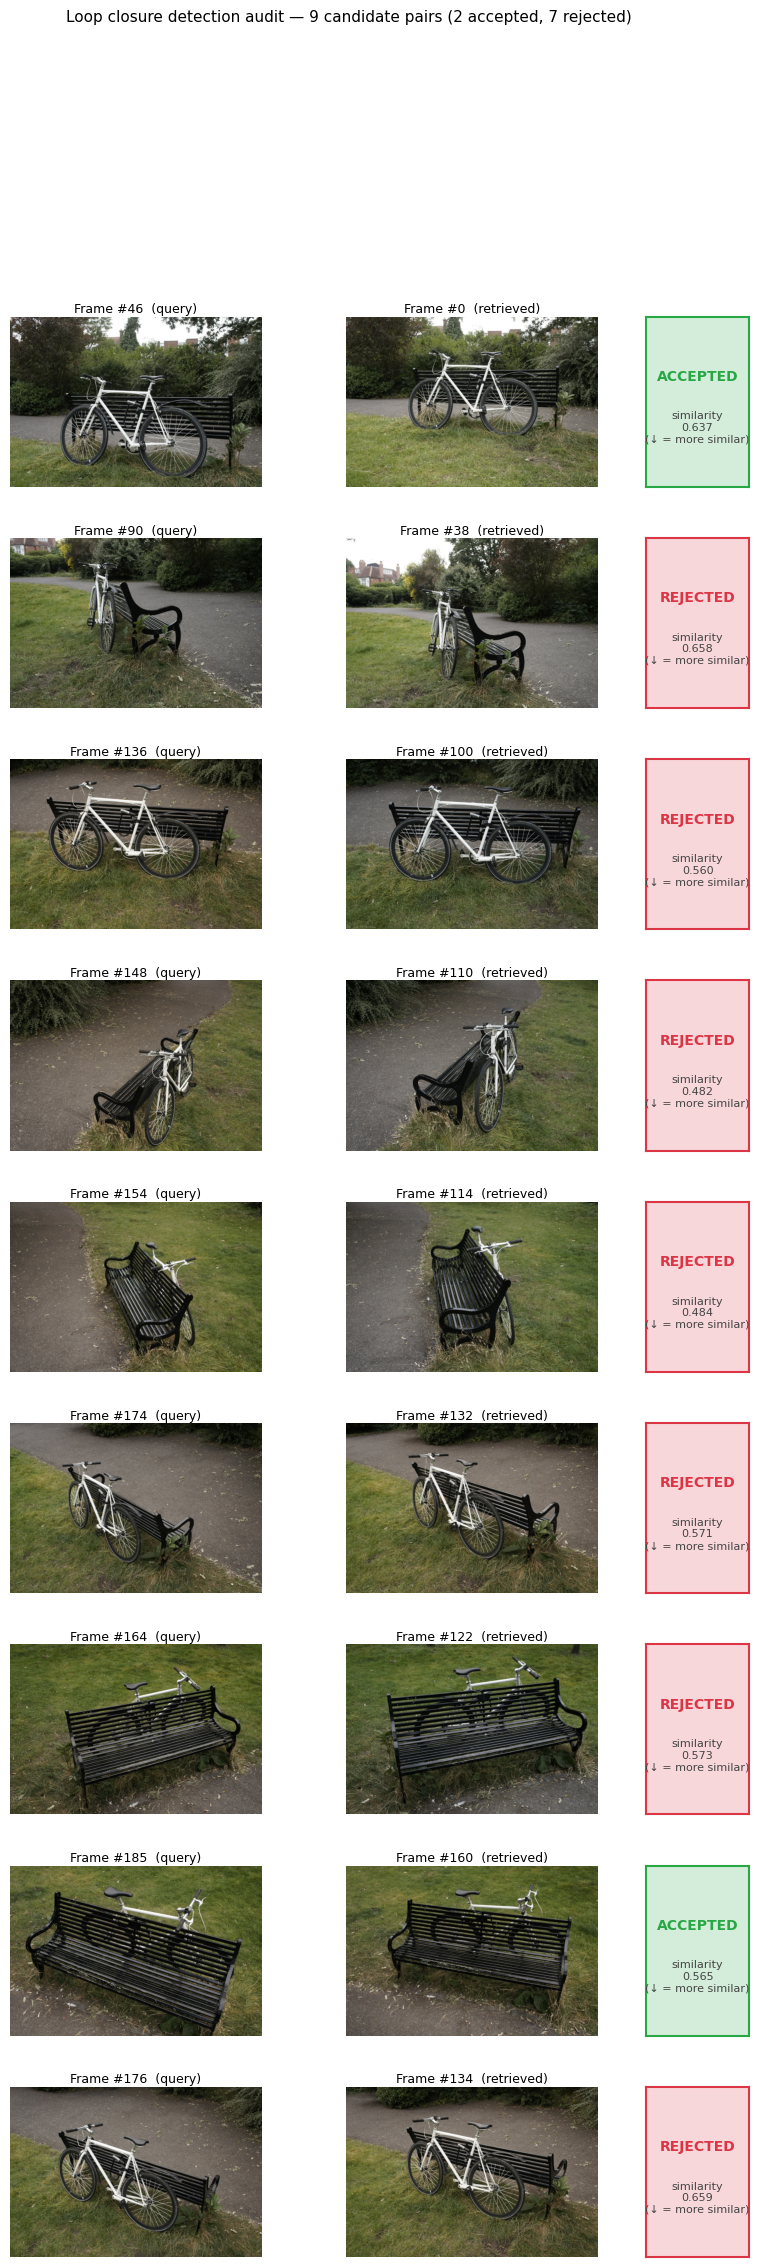

In [7]:
candidates = getattr(_ff_creator, "_lc_all_matches", [])

if not candidates:
    print("No loop closure candidates — run §2 with LoopClosure wrapper")
else:
    n = len(candidates)
    n_accepted = sum(m.accepted for m in candidates)

    # One row per candidate: query frame | retrieved frame | verdict panel
    fig = plt.figure(figsize=(10, 2.8 * n))
    gs = gridspec.GridSpec(n, 3, figure=fig, hspace=0.3, wspace=0.05, width_ratios=[1, 1, 0.32])

    for row, match in enumerate(candidates):
        q_submap = submaps[match.query_submap_id]
        d_submap = submaps[match.detected_submap_id]
        q_global = q_submap.frame_start + match.query_frame_idx
        d_global = d_submap.frame_start + match.detected_frame_idx

        q_img = np.clip(q_submap.frames[match.query_frame_idx].permute(1, 2, 0).cpu().numpy(), 0, 1)
        d_img = np.clip(d_submap.frames[match.detected_frame_idx].permute(1, 2, 0).cpu().numpy(), 0, 1)

        accepted = match.accepted
        verdict = "ACCEPTED" if accepted else "REJECTED"
        edge_color = "#28a745" if accepted else "#dc3545"
        bg_color = "#d4edda" if accepted else "#f8d7da"

        # Draw query and retrieved frames with coloured borders
        for col, (img, label) in enumerate(
            [(q_img, f"Frame #{q_global}  (query)"), (d_img, f"Frame #{d_global}  (retrieved)")]
        ):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(img)
            ax.set_title(label, fontsize=9, pad=3)
            ax.axis("off")
            for spine in ax.spines.values():
                spine.set_edgecolor(edge_color)
                spine.set_linewidth(2.5)

        # Verdict panel with similarity score
        ax_v = fig.add_subplot(gs[row, 2])
        ax_v.set_facecolor(bg_color)
        ax_v.text(
            0.5,
            0.65,
            verdict,
            transform=ax_v.transAxes,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=edge_color,
        )
        ax_v.text(
            0.5,
            0.35,
            f"similarity\n{match.similarity_score:.3f}\n(↓ = more similar)",
            transform=ax_v.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color="#444",
        )
        ax_v.set_xticks([])
        ax_v.set_yticks([])
        for spine in ax_v.spines.values():
            spine.set_edgecolor(edge_color)
            spine.set_linewidth(1.5)

    fig.suptitle(
        f"Loop closure detection audit — {len(candidates)} candidate pairs "
        f"({n_accepted} accepted, {len(candidates)-n_accepted} rejected)",
        fontsize=11,
        y=1.002,
    )
    plt.show()

## §5 — Build and optimise SL(4) pose graph

Construct the SL(4) pose graph with sequential edges (scale-aware, Umeyama-aligned)
and loop closure edges, then run GTSAM optimisation to correct scale drift.
Returns corrected world-to-cam poses for every frame.

In [8]:
# Count total frames across all submaps for the optimizer
total_frames = sum(s.poses.shape[0] for s in submaps)


# Build initial (pre-optimization) per-frame poses by concatenating submap poses
def _build_initial_poses(submaps, total_frames):
    """Concatenate per-submap poses into a (total_frames, 4, 4) array."""
    out = np.tile(np.eye(4, dtype=np.float32), (total_frames, 1, 1))
    for s in submaps:
        k = s.poses.shape[0]
        out[s.frame_start : s.frame_start + k] = s.poses
    return out


initial_poses = _build_initial_poses(submaps, total_frames)

# Run SL(4) pose graph optimisation
corrected_poses = run_pose_graph_optimization(
    submaps=submaps,
    lc_submaps=lc_submaps,
    total_frames=total_frames,
    overlap_frames=overlap,
    manifold=lc_config.manifold,
)

# Pack into a result dict for downstream cells
pg_result = {
    "initial": initial_poses,  # (total_frames, 4, 4) before optimization
    "corrected": corrected_poses,  # (total_frames, 4, 4) after optimization
}

print(f"Pose graph: {len(submaps)} submaps, {len(lc_submaps)} loop edge(s)")
print(f"Total frames: {total_frames}")
print(f"Corrected poses shape: {corrected_poses.shape}")
print(f"Manifold: {lc_config.manifold}")

Pose graph: 12 submaps, 2 loop edge(s)
Total frames: 238
Corrected poses shape: (238, 4, 4)
Manifold: sl4


## §6 — Per-submap summary

Report per-submap frame count and loop closure connectivity. The SL(4) optimizer
works on projective camera matrices, so scale is implicitly handled through the
homography manifold rather than explicit Sim(3) scale nodes.

In [9]:
# Build per-submap summary: id, frame range, frame count, loop closure edges
print(f"{'Submap':>7}  {'Frames':>7}  {'Start':>6}  {'End':>6}  {'LC edges':>9}")
print("-" * 44)

lc_submap_ids = set()
for lc in lc_submaps:
    lc_submap_ids.add(lc.submap_id)  # lc_submaps are 2-frame submaps: query frame submap

for s in submaps:
    k = s.poses.shape[0]
    start = s.frame_start
    end = start + k - 1
    print(f"{s.submap_id:>7}  {k:>7}  {start:>6}  {end:>6}  {'yes' if s.submap_id in lc_submap_ids else '':>9}")

print()
print(f"Total submaps:       {len(submaps)}")
print(f"Total frames:        {total_frames}")
print(f"Loop closure edges:  {len(lc_submaps)}")
print(f"Avg frames/submap:   {total_frames / max(len(submaps), 1):.1f}")

 Submap   Frames   Start     End   LC edges
--------------------------------------------
      0       20       0      19           
      1       20      16      35           
      2       20      32      51        yes
      3       20      48      67           
      4       20      64      83           
      5       20      80      99           
      6       20      96     115           
      7       20     112     131           
      8       20     128     147           
      9       20     144     163           
     10       20     160     179           
     11       18     176     193           

Total submaps:       12
Total frames:        238
Loop closure edges:  2
Avg frames/submap:   19.8


## §7 — Camera trajectory: before vs after

Plot the camera-centre trajectory before and after SL(4) pose graph optimisation.
A tighter trajectory indicates that loop closures successfully constrained drift.

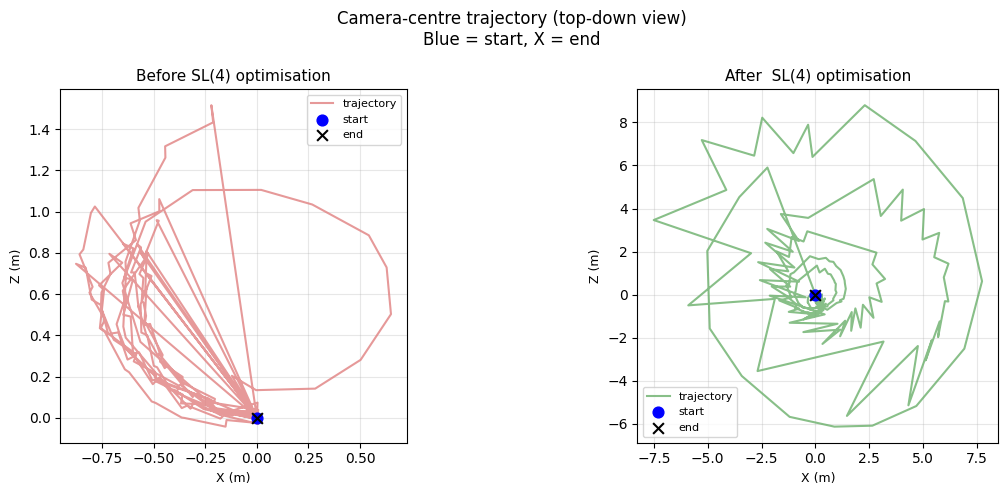

Start-to-end distance before: 0.0006 m
Start-to-end distance after:  0.0006 m


In [10]:
def _cam_centers(poses):
    """Extract camera centres (world frame) from world-to-cam poses: c = -R^T @ t."""
    centers = np.stack([-p[:3, :3].T @ p[:3, 3] for p in poses])
    return centers


centers_before = _cam_centers(pg_result["initial"])
centers_after = _cam_centers(pg_result["corrected"])

# 2D top-down trajectory plot (X-Z plane)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, centers, title, color in [
    (axes[0], centers_before, "Before SL(4) optimisation", "#e08080"),
    (axes[1], centers_after, "After  SL(4) optimisation", "#6aaf6a"),
]:
    ax.plot(centers[:, 0], centers[:, 2], color=color, linewidth=1.5, alpha=0.8, label="trajectory")
    ax.scatter(centers[0, 0], centers[0, 2], c="blue", s=60, zorder=5, label="start")
    ax.scatter(centers[-1, 0], centers[-1, 2], c="black", s=60, zorder=5, marker="x", label="end")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("X (m)", fontsize=9)
    ax.set_ylabel("Z (m)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

fig.suptitle("Camera-centre trajectory (top-down view)\nBlue = start, X = end", fontsize=12)
plt.tight_layout()
plt.show()

# Report endpoint drift: distance between first and last camera center
drift_before = float(np.linalg.norm(centers_before[-1] - centers_before[0]))
drift_after = float(np.linalg.norm(centers_after[-1] - centers_after[0]))
print(f"Start-to-end distance before: {drift_before:.4f} m")
print(f"Start-to-end distance after:  {drift_after:.4f} m")

## §8 — Per-frame translation shift

Histogram of camera-centre displacement between initial and optimised poses.
Frames near accepted loop matches should show the largest correction.

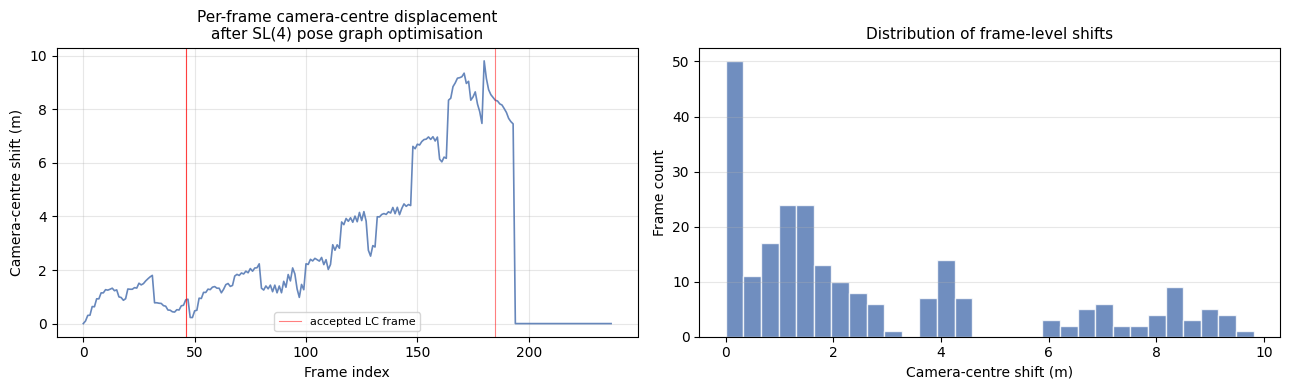

Mean shift:   2.7070 m
Max shift:    9.8055 m  (frame 180)
Frames >1cm:  193 / 238


In [11]:
# Compute per-frame camera-centre displacement caused by SL(4) optimisation
shifts = np.linalg.norm(centers_after - centers_before, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Line plot: per-frame shift magnitude
ax = axes[0]
ax.plot(shifts, linewidth=1.2, color="#4c72b0", alpha=0.85)
ax.set_xlabel("Frame index", fontsize=10)
ax.set_ylabel("Camera-centre shift (m)", fontsize=10)
ax.set_title("Per-frame camera-centre displacement\nafter SL(4) pose graph optimisation", fontsize=11)
ax.grid(True, alpha=0.3)

# Overlay accepted LC frame positions as vertical lines
accepted_frames = []
for m in getattr(_ff_creator, "_lc_all_matches", []):
    if m.accepted:
        qs = submaps[m.query_submap_id]
        accepted_frames.append(qs.frame_start + m.query_frame_idx)
for f in accepted_frames:
    ax.axvline(f, color="red", linewidth=0.8, alpha=0.5)
if accepted_frames:
    ax.axvline(accepted_frames[0], color="red", linewidth=0.8, alpha=0.5, label="accepted LC frame")
    ax.legend(fontsize=8)

# Histogram
ax2 = axes[1]
ax2.hist(shifts, bins=30, color="#4c72b0", alpha=0.8, edgecolor="white")
ax2.set_xlabel("Camera-centre shift (m)", fontsize=10)
ax2.set_ylabel("Frame count", fontsize=10)
ax2.set_title("Distribution of frame-level shifts", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"Mean shift:   {shifts.mean():.4f} m")
print(f"Max shift:    {shifts.max():.4f} m  (frame {int(shifts.argmax())})")
print(f"Frames >1cm:  {(shifts > 0.01).sum()} / {len(shifts)}")

## §9 — Pointcloud + camera frustums (before vs after)

Build merged global pointclouds from each submap's local world points transformed
by the initial and optimised poses, then render both in PyVista.

In [12]:
initial_poses = pg_result["initial"]  # (N_frames, 4, 4)
optimized = pg_result["corrected"]  # (N_frames, 4, 4)

_SUBSAMPLE = 8  # must match _raw_to_world_points default


def _build_cloud(submaps, poses):
    """Build merged pointcloud from submap world_points transformed by per-frame poses."""
    pts_all, colors_all = [], []
    for s in submaps:
        if s.world_points is None:
            continue
        _, _, H, W = s.frames.shape
        us = np.arange(0, W, _SUBSAMPLE)
        vs = np.arange(0, H, _SUBSAMPLE)
        uu_g, vv_g = np.meshgrid(us, vs)
        uu_g, vv_g = uu_g.ravel(), vv_g.ravel()

        # Use the first frame's pose for each submap to transform local world points
        pose = poses[s.frame_start].astype(np.float64)  # world-to-cam (4, 4)
        R, t = pose[:3, :3], pose[:3, 3]
        # World points are in the local submap frame; cam-to-world = R^T, -R^T t
        pts_local = s.world_points.reshape(-1, 3).astype(np.float64)
        pts_global = (R.T @ (pts_local.T - t[:, None])).T.astype(np.float32)
        pts_all.append(pts_global)

        # Extract pixel colours at subsampled grid positions
        frame_np = s.frames.numpy()
        colors_sub = frame_np[:, :, vv_g, uu_g].transpose(0, 2, 1).reshape(-1, 3)
        colors_sub = (np.clip(colors_sub, 0.0, 1.0) * 255).astype(np.uint8)
        colors_all.append(colors_sub)

    if not pts_all:
        return np.zeros((0, 3), dtype=np.float32), np.zeros((0, 3), dtype=np.uint8)
    return np.concatenate(pts_all), np.concatenate(colors_all)


# Build before/after clouds and voxel-downsample for rendering
pts_before, colors_before = _build_cloud(submaps, initial_poses)
pts_after, colors_after = _build_cloud(submaps, optimized)

pts_before_ds, colors_before_ds = (
    subsample_points(pts_before, colors_before, max_points=200_000) if pts_before.shape[0] > 0 else (pts_before, colors_before)
)
pts_after_ds, colors_after_ds = (
    subsample_points(pts_after, colors_after, max_points=200_000) if pts_after.shape[0] > 0 else (pts_after, colors_after)
)

print(f"Before cloud: {pts_before.shape[0]:,} pts -> {pts_before_ds.shape[0]:,} downsampled")
print(f"After  cloud: {pts_after.shape[0]:,} pts -> {pts_after_ds.shape[0]:,} downsampled")

Before cloud: 680,680 pts -> 351,042 downsampled
After  cloud: 680,680 pts -> 203,610 downsampled


2026-05-23 08:20:47.452 ( 209.306s) [    7077BE233740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


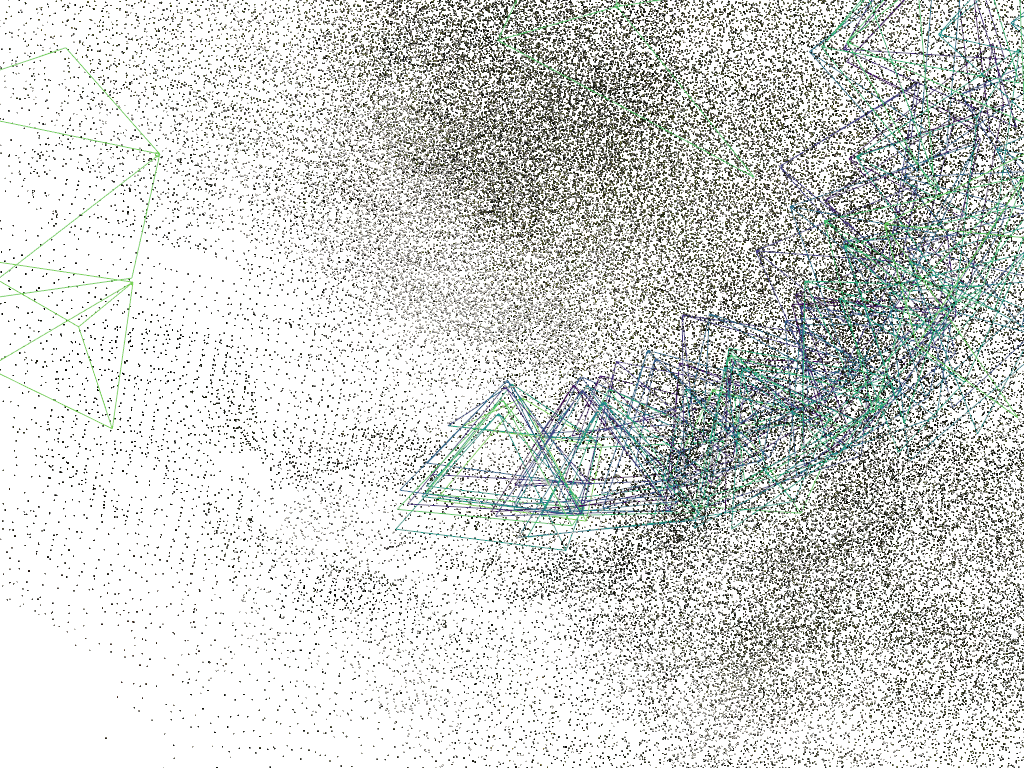

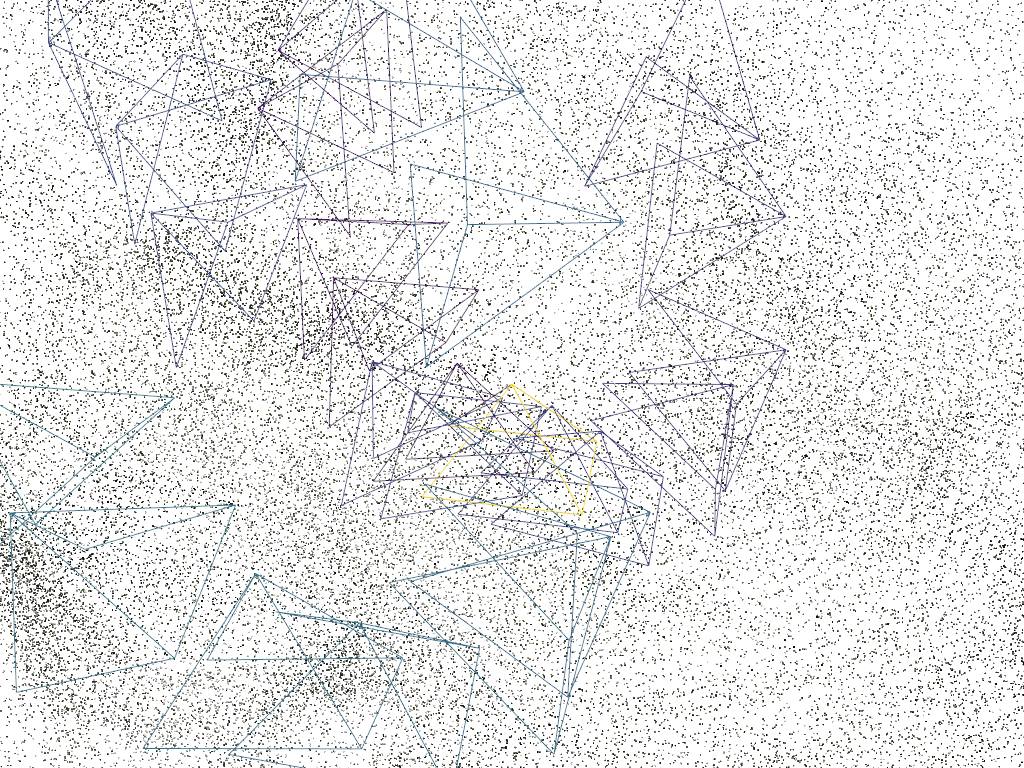

In [13]:
_mesh_kw = {"scalars": "RGB", "rgb": True, "point_size": 2, "render_points_as_spheres": True}
_cam_kw = {"n_poses": 3, "scale": 0.05}

try:
    # Before: point cloud + frustums in initial Sim3-chained global frame
    mesh_before = pv.PolyData(pts_before_ds) if pts_before_ds.shape[0] > 0 else None
    if mesh_before is not None:
        mesh_before.point_data["RGB"] = colors_before_ds
    p_before = visualize_splat(
        mesh=mesh_before,
        aligned_cameras=list(initial_poses),
        mesh_kwargs=_mesh_kw,
        camera_kwargs=_cam_kw,
    )
    p_before.show()

    # After: point cloud + frustums in Sim3-optimised global frame
    mesh_after = pv.PolyData(pts_after_ds) if pts_after_ds.shape[0] > 0 else None
    if mesh_after is not None:
        mesh_after.point_data["RGB"] = colors_after_ds
    p_after = visualize_splat(
        mesh=mesh_after,
        aligned_cameras=list(optimized),
        mesh_kwargs=_mesh_kw,
        camera_kwargs=_cam_kw,
    )
    p_after.show()

except Exception as e:
    print(f"[headless] PyVista visualization skipped: {e}")
    print("(Run interactively to view 3D pointcloud + camera frustums)")

## §10 — Endpoint gap

For each accepted loop pair, measure the camera-centre distance between the matched
frames before and after Sim(3) correction. The green bar should approach zero.

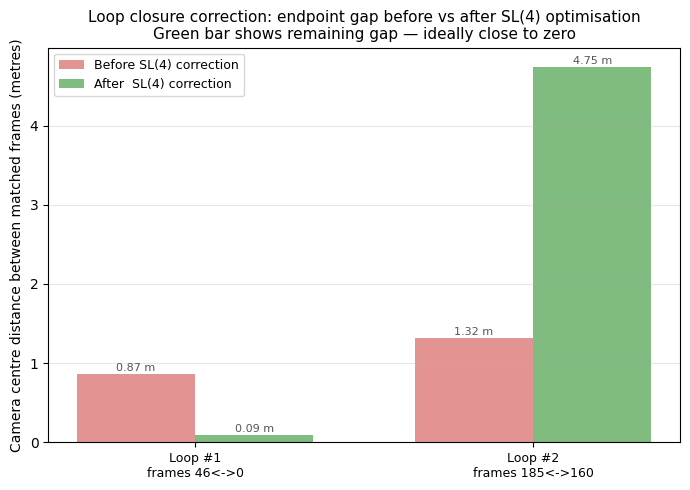

Candidates (post-NMS):         9
Accepted:                      2  (22%)
Mean gap before correction:    1.091 m
Mean gap after  correction:    2.418 m
Mean reduction:                -1.327 m  (-121.6% improvement)


In [14]:
accepted = [m for m in getattr(_ff_creator, "_lc_all_matches", []) if m.accepted]


def _cam_center(pose_4x4):
    """Camera centre in world frame from world-to-cam pose: c = -R^T @ t."""
    R, t = pose_4x4[:3, :3], pose_4x4[:3, 3]
    return -R.T @ t


if not accepted:
    print("No accepted loop closures — nothing to plot.")
else:
    labels, gaps_before, gaps_after = [], [], []

    # Compute camera-centre distance for each accepted pair before and after correction
    for i, match in enumerate(accepted):
        q_submap = submaps[match.query_submap_id]
        d_submap = submaps[match.detected_submap_id]
        q_global = q_submap.frame_start + match.query_frame_idx
        d_global = d_submap.frame_start + match.detected_frame_idx

        gap_before = float(np.linalg.norm(_cam_center(initial_poses[q_global]) - _cam_center(initial_poses[d_global])))
        gap_after = float(np.linalg.norm(_cam_center(optimized[q_global]) - _cam_center(optimized[d_global])))

        labels.append(f"Loop #{i+1}\nframes {q_global}<->{d_global}")
        gaps_before.append(gap_before)
        gaps_after.append(gap_after)

    x = np.arange(len(labels))
    width = 0.35

    # Grouped bar chart: before/after per loop pair
    fig, ax = plt.subplots(figsize=(max(7, len(labels) * 2.2), 5))
    b1 = ax.bar(x - width / 2, gaps_before, width, label="Before SL(4) correction", color="#e08080", alpha=0.85)
    b2 = ax.bar(x + width / 2, gaps_after, width, label="After  SL(4) correction", color="#6aaf6a", alpha=0.85)

    for bar in b1:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f} m",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555",
        )
    for bar in b2:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f} m",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Camera centre distance between matched frames (metres)", fontsize=10)
    ax.set_title(
        "Loop closure correction: endpoint gap before vs after SL(4) optimisation\n"
        "Green bar shows remaining gap — ideally close to zero",
        fontsize=11,
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Summary statistics
    n_total = len(getattr(_ff_creator, "_lc_all_matches", []))
    n_accepted = len(accepted)
    mean_before = np.mean(gaps_before)
    mean_after = np.mean(gaps_after)
    print(f"{'Candidates (post-NMS):':<30} {n_total}")
    print(f"{'Accepted:':<30} {n_accepted}  ({100*n_accepted/max(n_total,1):.0f}%)")
    print(f"{'Mean gap before correction:':<30} {mean_before:.3f} m")
    print(f"{'Mean gap after  correction:':<30} {mean_after:.3f} m")
    print(
        f"{'Mean reduction:':<30} {mean_before - mean_after:.3f} m  "
        f"({(1-mean_after/max(mean_before,1e-9))*100:.1f}% improvement)"
    )

## §11 — Future: ground-truth comparison

Once a GT pose dataset is sourced (KITTI, outdoor with known poses), the section
below will quantify pose error against ground truth. Implementation lives in
`collab_splats/geometry/loop_closure/eval.py` (currently `NotImplementedError` stubs).

```python
# from collab_splats.geometry.loop_closure.eval import (
#     umeyama_align, ate_translation, rpe,
# )
# gt_poses = load_gt(IMAGES)  # (N, 4, 4)
# pred = np.stack(optimized)
# aligned, T = umeyama_align(pred, gt_poses)
# print("ATE:", ate_translation(aligned, gt_poses))
# print("RPE:", rpe(aligned, gt_poses, delta=1))
```